# SHAP Visualization — Single URL Prediction

Loads the saved model bundle and visualises SHAP explanations for one phishing and one legitimate URL.

**Plots:** Waterfall, Bar, Force plot  
**Colors:** `#239DD9` (legitimate) / `#FF911E` (phishing)

## SECTION 1 — Imports

In [5]:
import sys
sys.path.insert(0, '../api')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import shap
import joblib
from pathlib import Path

import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

COLOR_LEGIT  = '#239DD9'
COLOR_PHISH  = '#FF911E'

print('Libraries loaded.')

Libraries loaded.


## SECTION 2 — Load Model Bundle

In [6]:
models_dir = Path('./models')
bundles = sorted(models_dir.glob('deploy_*.pkl'))
if not bundles:
    raise FileNotFoundError('No model bundle found in models/. Run 03_modeling.ipynb first.')

bundle_path = bundles[-1]
print(f'Loading: {bundle_path.name}')

bundle    = joblib.load(bundle_path)
model     = bundle['model']
FEATURES  = bundle['features']
threshold = bundle['threshold']
model_name = bundle['model_name']

print(f'Model:     {model_name}')
print(f'Features:  {len(FEATURES)}')
print(f'Threshold: {threshold:.4f}')

Loading: deploy_XGBoost_20260404_104433.pkl
Model:     XGBoost
Features:  21
Threshold: 0.5095


## SECTION 3 — Feature Extraction

In [7]:
import importlib.util, sys
_spec = importlib.util.spec_from_file_location("predictor", "./api/predictor.py")
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
extract_features = _mod.extract_features

URL_PHISHING  = 'http://paypal-secure-login.verify-account.com/update'
URL_LEGIT     = 'https://github.com/topics/machine-learning'

def get_features(url):
    raw = extract_features(url)
    feat_log = np.log1p(np.array([raw[f] for f in FEATURES], dtype=float))
    return pd.DataFrame([feat_log], columns=FEATURES)

X_phish = get_features(URL_PHISHING)
X_legit = get_features(URL_LEGIT)

prob_phish = model.predict_proba(X_phish)[0, 1]
prob_legit = model.predict_proba(X_legit)[0, 1]

conf_phish = prob_phish * 100
conf_legit = (1 - prob_legit) * 100

print(f'Phishing URL  → prob={prob_phish:.4f}  | {"PHISHING" if prob_phish >= threshold else "LEGITIMATE"}  (confidence: {conf_phish:.1f}%)')
print(f'Legitimate URL→ prob={prob_legit:.4f}  | {"PHISHING" if prob_legit >= threshold else "LEGITIMATE"}  (confidence: {conf_legit:.1f}%)')

Phishing URL  → prob=1.0000  | PHISHING  (confidence: 100.0%)
Legitimate URL→ prob=0.0273  | LEGITIMATE  (confidence: 97.3%)


## SECTION 4 — SHAP Explainer

In [8]:
# Detect Pipeline (LogReg) vs tree model
if hasattr(model, 'named_steps'):
    clf_step    = model.named_steps['clf']
    scaler_step = model.named_steps['scaler']
    bg = pd.DataFrame(
        scaler_step.transform(X_phish),  # background placeholder
        columns=FEATURES
    )
    explainer = shap.LinearExplainer(clf_step, bg)
    X_phish_shap = pd.DataFrame(scaler_step.transform(X_phish), columns=FEATURES)
    X_legit_shap = pd.DataFrame(scaler_step.transform(X_legit), columns=FEATURES)
else:
    explainer    = shap.TreeExplainer(model)
    X_phish_shap = X_phish
    X_legit_shap = X_legit

sv_phish = explainer(X_phish_shap)
sv_legit = explainer(X_legit_shap)

print('SHAP values computed.')

SHAP values computed.


## SECTION 5 — Waterfall Plot

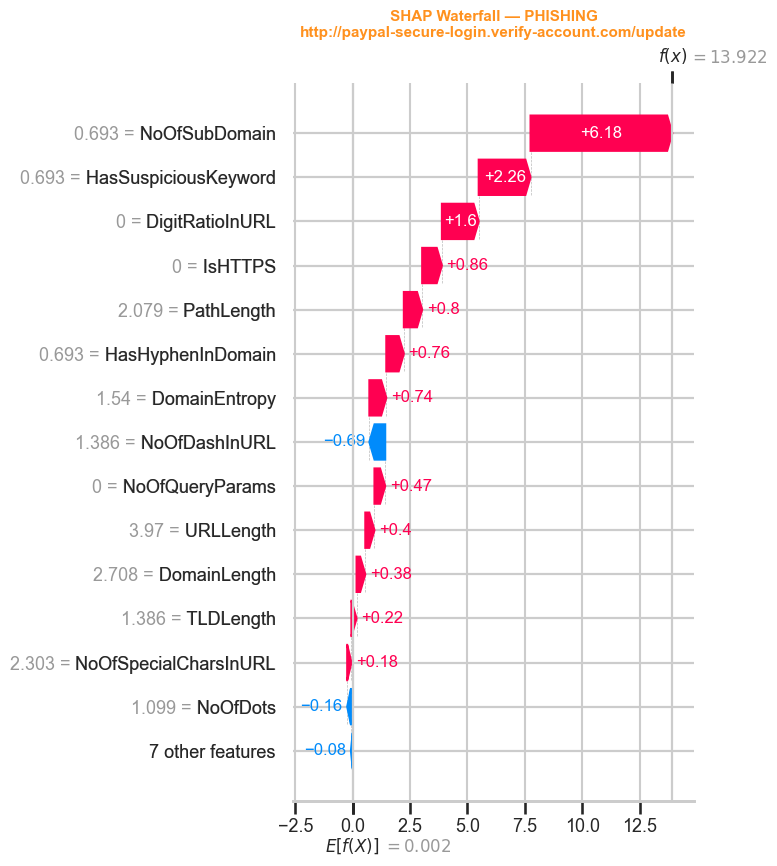

In [9]:
# Phishing waterfall
shap.plots.waterfall(sv_phish[0], max_display=15, show=False)
plt.title(f'SHAP Waterfall — PHISHING\n{URL_PHISHING}', fontsize=11, fontweight='bold', color=COLOR_PHISH)
plt.tight_layout()
plt.show()

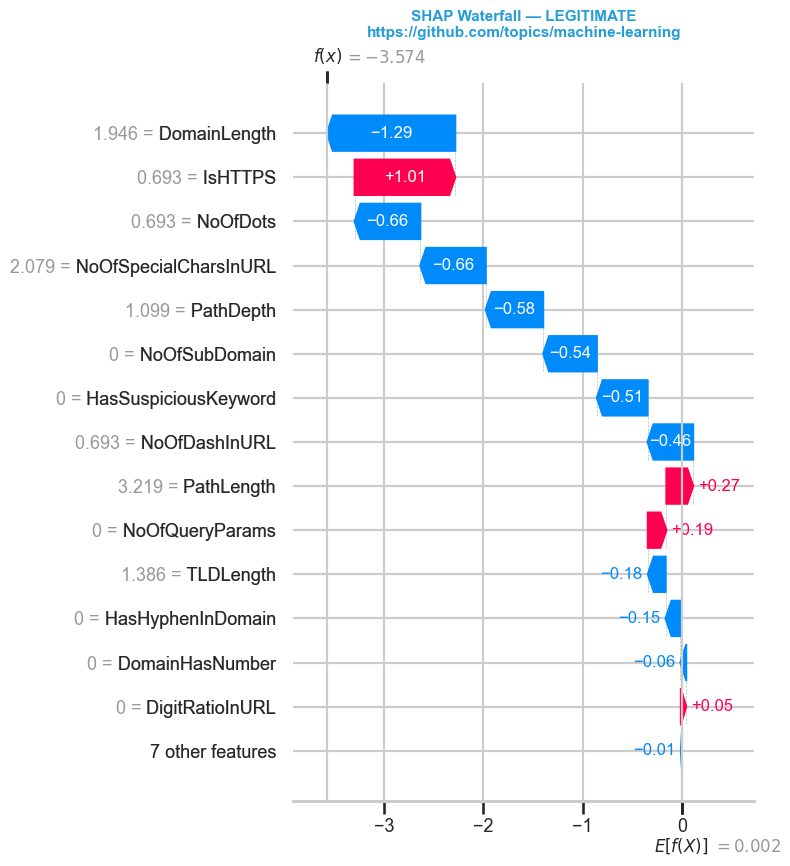

In [10]:
# Legitimate waterfall
shap.plots.waterfall(sv_legit[0], max_display=15, show=False)
plt.title(f'SHAP Waterfall — LEGITIMATE\n{URL_LEGIT}', fontsize=11, fontweight='bold', color=COLOR_LEGIT)
plt.tight_layout()
plt.show()

## SECTION 6 — Bar Plot

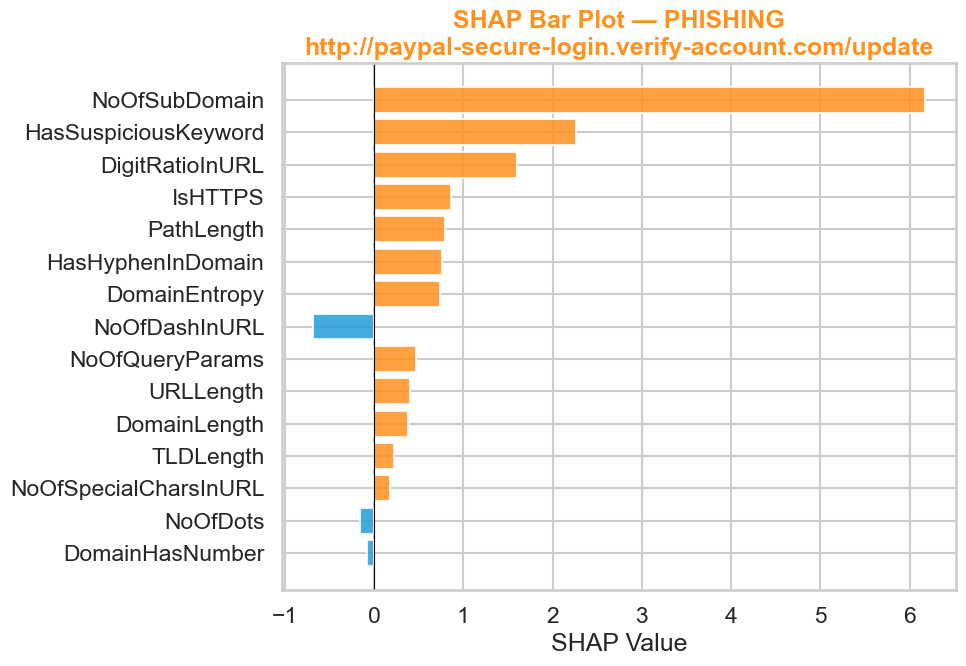

In [11]:
# Phishing bar
shap_vals_phish = sv_phish[0].values
sorted_idx = np.argsort(np.abs(shap_vals_phish))[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 7))
vals  = shap_vals_phish[sorted_idx]
feats = [FEATURES[i] for i in sorted_idx]
colors = [COLOR_PHISH if v > 0 else COLOR_LEGIT for v in vals]

ax.barh(feats[::-1], vals[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value')
ax.set_title(f'SHAP Bar Plot — PHISHING\n{URL_PHISHING}', fontweight='bold', color=COLOR_PHISH)
plt.tight_layout()
plt.show()

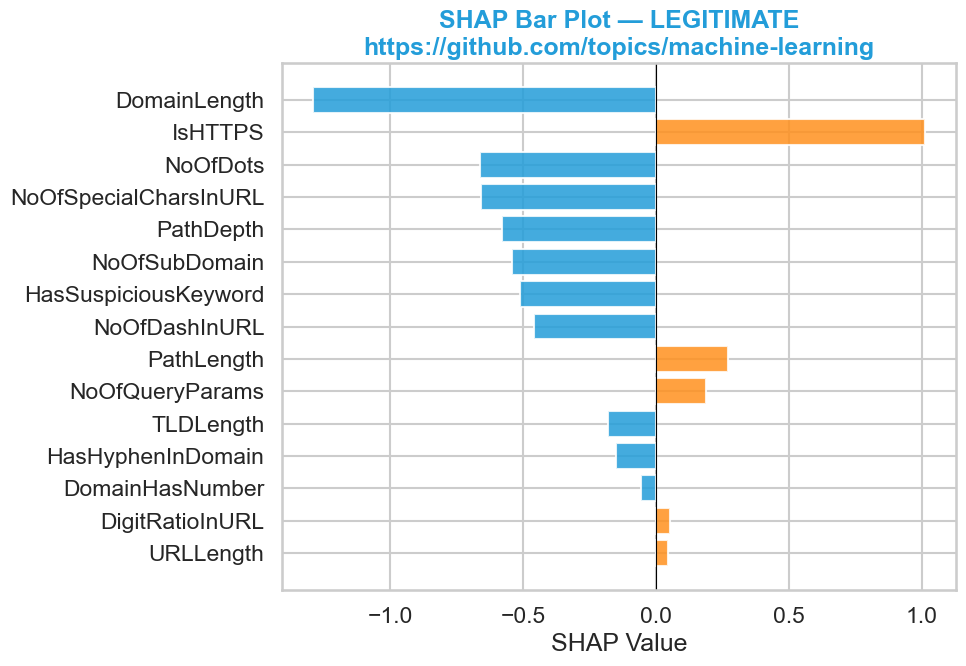

In [12]:
# Legitimate bar
shap_vals_legit = sv_legit[0].values
sorted_idx = np.argsort(np.abs(shap_vals_legit))[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 7))
vals  = shap_vals_legit[sorted_idx]
feats = [FEATURES[i] for i in sorted_idx]
colors = [COLOR_PHISH if v > 0 else COLOR_LEGIT for v in vals]

ax.barh(feats[::-1], vals[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value')
ax.set_title(f'SHAP Bar Plot — LEGITIMATE\n{URL_LEGIT}', fontweight='bold', color=COLOR_LEGIT)
plt.tight_layout()
plt.show()

## SECTION 7 — Force Plot

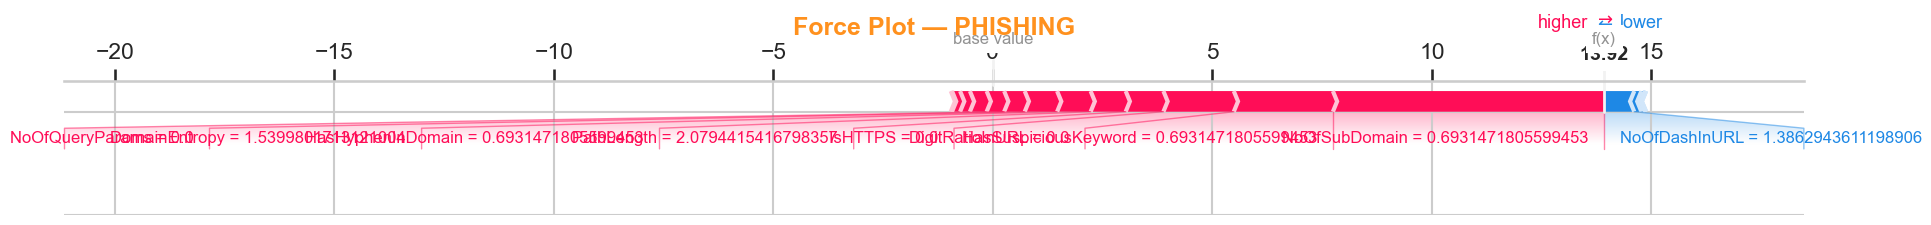

In [13]:
shap.initjs()

# Phishing force plot
force_phish = shap.force_plot(
    sv_phish[0].base_values,
    sv_phish[0].values,
    X_phish_shap,
    feature_names=FEATURES,
    matplotlib=True,
    show=False,
    plot_cmap=[COLOR_PHISH, COLOR_LEGIT]
)
plt.title(f'Force Plot — PHISHING', fontweight='bold', color=COLOR_PHISH)
plt.tight_layout()
plt.show()

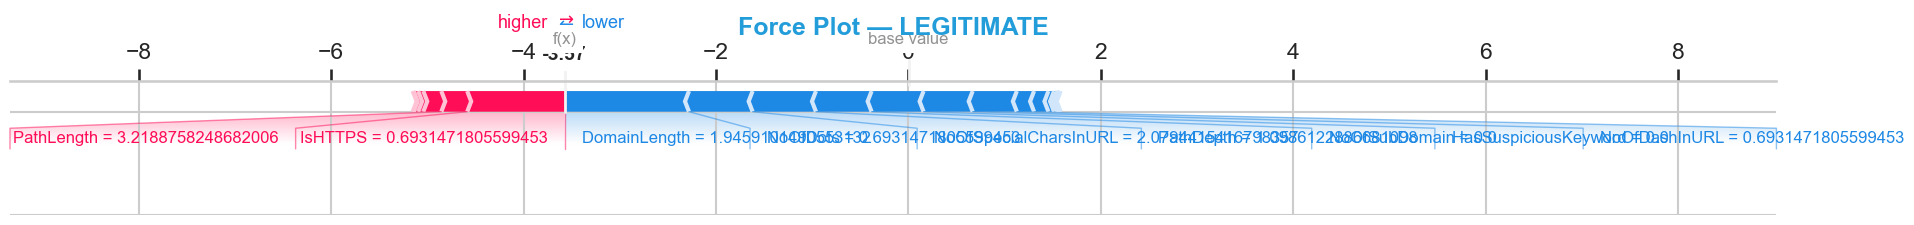

In [14]:
# Legitimate force plot
force_legit = shap.force_plot(
    sv_legit[0].base_values,
    sv_legit[0].values,
    X_legit_shap,
    feature_names=FEATURES,
    matplotlib=True,
    show=False,
    plot_cmap=[COLOR_PHISH, COLOR_LEGIT]
)
plt.title(f'Force Plot — LEGITIMATE', fontweight='bold', color=COLOR_LEGIT)
plt.tight_layout()
plt.show()